In [1]:
# ============================================================
# CELL 1: Install libraries and connect Google Drive
# ============================================================
# Here's what each library does:
#   - torch / torchvision : PyTorch, the ML framework we use to build & train our model
#   - opencv (cv2)        : Opens and reads video files, extracts individual frames
#   - pillow (PIL)        : Works with images (resizing, converting formats, etc.)
#   - scikit-learn        : Helps us split data into train/test and evaluate results
#   - matplotlib          : Creates charts and plots so we can visualize our results

!pip install -q torch torchvision opencv-python-headless pillow

#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Libraries installed and Drive connected!")

Mounted at /content/drive
Libraries installed and Drive connected!


In [2]:
#============================================================
# CELL 2: Set up paths and verify your files exist
# ============================================================

import os

# ──── CHANGE THIS PATH if your folder name or location is different ────
BASE_PATH = "/content/drive/MyDrive/ai_reels_game"

# Build the full paths to each subfolder
AI_FOLDER = os.path.join(BASE_PATH, "ai")       # Where AI-generated clips live
REAL_FOLDER = os.path.join(BASE_PATH, "real")    # Where real clips live

# List all .mp4 files in each folder and sort them alphabetically
# The "if f.endswith('.mp4')" part filters out any non-video files
# (like .DS_Store or thumbs.db that your OS might have added)
ai_files = sorted([f for f in os.listdir(AI_FOLDER) if f.endswith('.mp4')])
real_files = sorted([f for f in os.listdir(REAL_FOLDER) if f.endswith('.mp4')])

# Print what we found — the [:3] means "show just the first 3 filenames"
print(f"Found {len(ai_files)} AI clips: {ai_files[:3]} ...")
print(f"Found {len(real_files)} Real clips: {real_files[:3]} ...")
print(f"\nTotal clips: {len(ai_files) + len(real_files)}")

Found 33 AI clips: ['ai (1).mp4', 'ai (10).mp4', 'ai (11).mp4'] ...
Found 33 Real clips: ['real (1).mp4', 'real (10).mp4', 'real (11).mp4'] ...

Total clips: 66


In [3]:
#============================================================
# CELL 3: Extract frames from videos and SAVE TO DISK
# ============================================================
#
# WHAT THIS DOES:
# Our ML model is an IMAGE classifier — it looks at still images,
# not videos. So we need to convert each video into a handful of
# representative still images (called "frames").
#
# Think of a video as a flipbook with hundreds of pages. We're
# picking 5 pages spread evenly throughout the book.
#
# RAM-SAVING STRATEGY:
# Instead of holding all frames in memory (which will crash in free Colab),
# we immediately SAVE each frame as a small .jpg file to disk
# and only store the file paths. This keeps RAM usage very low
# because we're only storing a list of text strings (file paths),
# not actual image data.
#
# The saved frames go into: /content/frames/ (Colab's local storage)
# This is temporary storage — it gets deleted when you disconnect,
# but that's fine because we can always re-extract.

import cv2
import numpy as np
from PIL import Image
import gc

# Create a folder on Colab's LOCAL disk to save extracted frames
# Using local disk (/content/) instead of Google Drive because
# reading/writing is much faster on local storage
FRAMES_DIR = "/content/frames"
os.makedirs(FRAMES_DIR, exist_ok=True)  # Create folder if it doesn't exist

def extract_and_save_frames(video_path, clip_id, n_frames=10):
    """
    Opens a video file, extracts n_frames evenly spaced frames,
    RESIZES them to 256×256, and SAVES them as .jpg files to disk.

    Instead of returning the actual images (which eat RAM), this
    returns a list of file paths where the images were saved.

    Parameters:
        video_path: Full file path to the .mp4 file
        clip_id:    A unique name for this clip (used in filenames)
        n_frames:   How many frames to extract

    Returns:
        A list of file paths (strings) to the saved frame images
    """
    # Open the video file
    cap = cv2.VideoCapture(video_path)

    # Find out how many total frames are in this video
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # If the video is empty or corrupted, skip it
    if total_frames == 0:
        print(f"Could not read: {video_path}")
        cap.release()
        return []

    # Calculate which frame numbers to grab
    frame_indices = [int(i * total_frames / n_frames) for i in range(n_frames)]

    saved_paths = []
    for idx in frame_indices:
        # Jump to the specific frame number
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        # Read that frame
        ret, frame = cap.read()

        if ret:
            # Convert from BGR (OpenCV's format) to RGB (standard format)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Convert to PIL Image and resize to 256×256 immediately
            # This saves disk space and RAM when we load it later
            pil_image = Image.fromarray(frame_rgb).resize((256, 256))

            # Save to disk as a .jpg file
            # Filename example: "ai_01_frame_0.jpg"
            save_path = os.path.join(FRAMES_DIR, f"{clip_id}_frame_{idx}.jpg")
            pil_image.save(save_path, quality=90)

            # Store just the path (a short string), not the image itself
            saved_paths.append(save_path)

            # Explicitly delete the image from memory — we don't need it anymore
            del frame, frame_rgb, pil_image

    cap.release()

    # Tell Python to clean up freed memory
    gc.collect()

    return saved_paths


# ──── Now extract and save frames from ALL clips ────
#
# We store a lightweight list of dictionaries. Each dictionary has:
#   - filename:     the original file name (e.g., "ai (1).mp4")
#   - label:        0 for Real, 1 for AI (numbers the model understands)
#   - label_name:   "real" or "ai" (human-readable)
#   - frame_paths:  list of FILE PATHS to the saved frame images
#
# Notice we store frame_paths (strings) instead of actual frames (images).
# A string like "/content/frames/ai_01_frame_0.jpg" takes ~50 bytes.
# An actual image would take ~500,000 bytes. That's a 10,000x saving!

all_data = []

print("Extracting frames from AI clips...")
for i, f in enumerate(ai_files):
    path = os.path.join(AI_FOLDER, f)

    # Create a clean ID for filenames (e.g., "ai_01")
    clip_id = f"ai_{i:02d}"

    frame_paths = extract_and_save_frames(path, clip_id)

    if frame_paths:
        all_data.append({
            "filename": f,
            "label": 1,                # 1 = AI generated
            "label_name": "ai",
            "frame_paths": frame_paths  # Just the paths, not the images!
        })
        print(f"{f} → {len(frame_paths)} frames saved")

print("\nExtracting frames from Real clips...")
for i, f in enumerate(real_files):
    path = os.path.join(REAL_FOLDER, f)
    clip_id = f"real_{i:02d}"
    frame_paths = extract_and_save_frames(path, clip_id)

    if frame_paths:
        all_data.append({
            "filename": f,
            "label": 0,                # 0 = Real
            "label_name": "real",
            "frame_paths": frame_paths
        })
        print(f"{f} → {len(frame_paths)} frames saved")

total_frames = sum(len(d["frame_paths"]) for d in all_data)
print(f"\nExtracted and saved {total_frames} frames from {len(all_data)} clips")
print(f"   Frames saved to: {FRAMES_DIR}")

Extracting frames from AI clips...
ai (1).mp4 → 10 frames saved
ai (10).mp4 → 10 frames saved
ai (11).mp4 → 10 frames saved
ai (12).mp4 → 10 frames saved
ai (13).mp4 → 10 frames saved
ai (14).mp4 → 10 frames saved
ai (15).mp4 → 10 frames saved
ai (16).mp4 → 10 frames saved
ai (17).mp4 → 10 frames saved
ai (18).mp4 → 10 frames saved
ai (19).mp4 → 10 frames saved
ai (2).mp4 → 10 frames saved
ai (20).mp4 → 10 frames saved
ai (21).mp4 → 10 frames saved
ai (22).mp4 → 10 frames saved
ai (23).mp4 → 10 frames saved
ai (24).mp4 → 10 frames saved
ai (25).mp4 → 10 frames saved
ai (26).mp4 → 10 frames saved
ai (27).mp4 → 10 frames saved
ai (28).mp4 → 10 frames saved
ai (29).mp4 → 10 frames saved
ai (3).mp4 → 10 frames saved
ai (30).mp4 → 10 frames saved
ai (31).mp4 → 10 frames saved
ai (32).mp4 → 10 frames saved
ai (33).mp4 → 10 frames saved
ai (4).mp4 → 10 frames saved
ai (5).mp4 → 10 frames saved
ai (6).mp4 → 10 frames saved
ai (7).mp4 → 10 frames saved
ai (8).mp4 → 10 frames saved
ai (9).mp4 → 

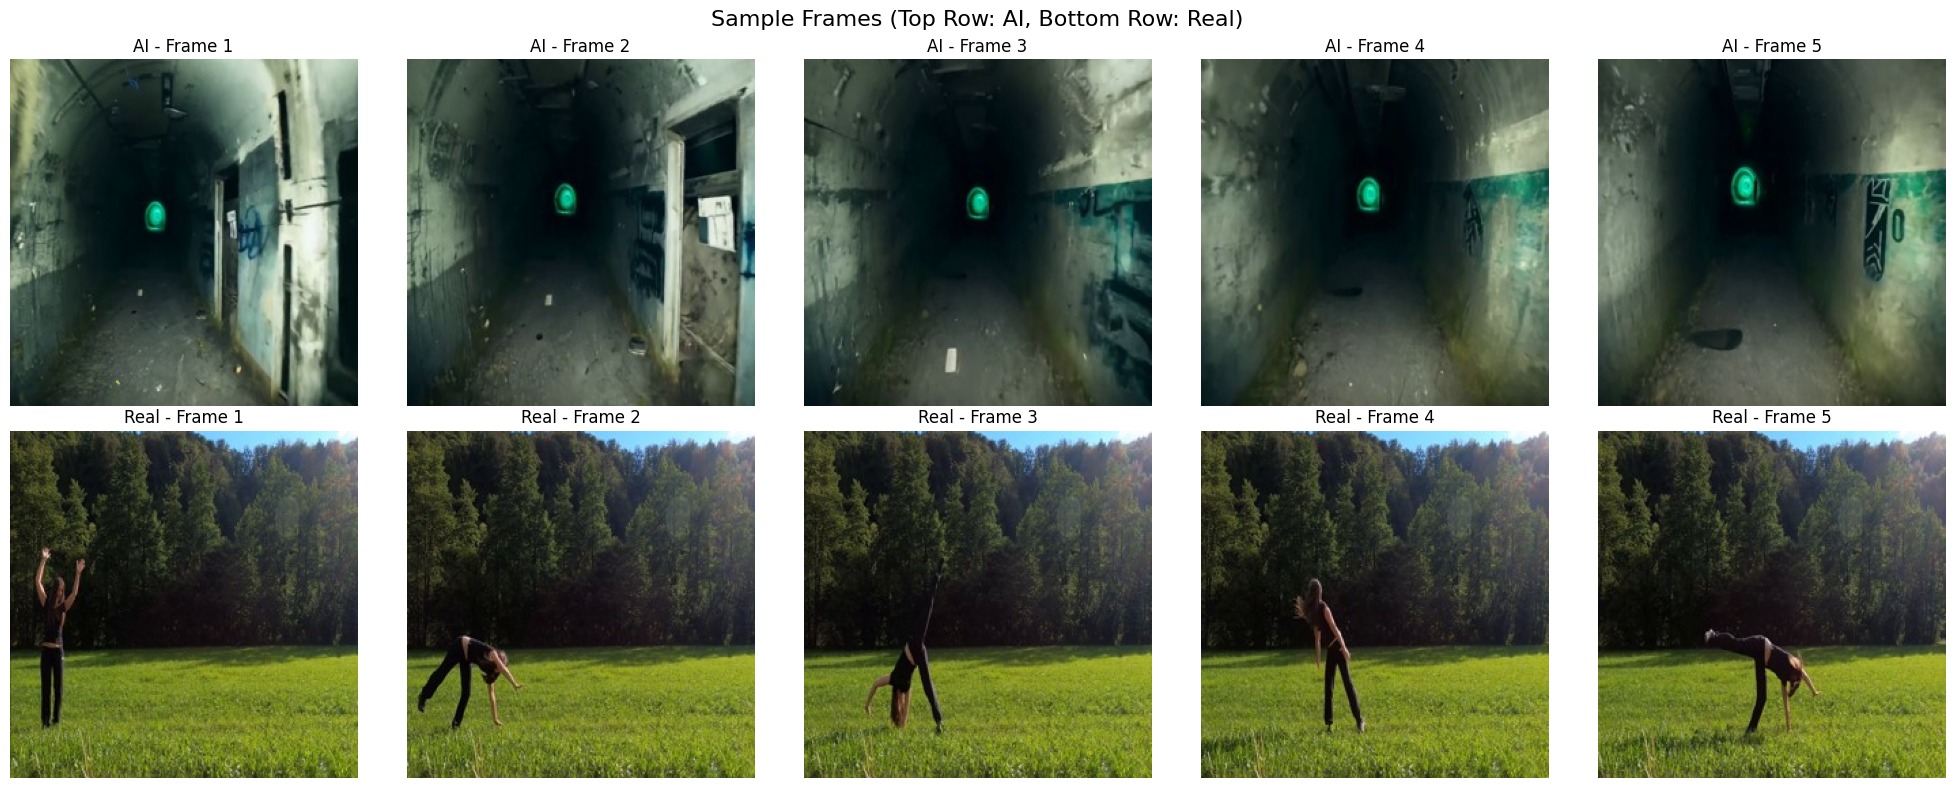

AI clip shown:   ai (22).mp4
Real clip shown: real (12).mp4


In [4]:
#============================================================
# CELL 4: Visualize some sample frames
# ============================================================
#
# WHAT THIS DOES:
# Before feeding data into a model, it's always good practice to
# LOOK at your data. This loads and shows 5 frames from a random AI clip
# and 5 frames from a random Real clip so you can visually confirm
# that the extraction worked correctly.
#
# We load the images temporarily just for display, then discard them.
# This only puts 10 images in RAM briefly

import matplotlib.pyplot as plt
import random

# Create a figure with 2 rows × 5 columns = 10 image slots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Sample Frames (Top Row: AI, Bottom Row: Real)", fontsize=16)

# Separate our data into AI clips and Real clips
ai_samples = [d for d in all_data if d["label"] == 1]
real_samples = [d for d in all_data if d["label"] == 0]

# Pick one random clip from each category
ai_clip = random.choice(ai_samples)
real_clip = random.choice(real_samples)

# Display the frames from the AI clip in the top row
# Image.open() loads one image at a time — very memory-friendly
for i, path in enumerate(ai_clip["frame_paths"][:5]):
    img = Image.open(path)        # Load from disk
    axes[0][i].imshow(img)
    axes[0][i].set_title(f"AI - Frame {i+1}")
    axes[0][i].axis("off")
    img.close()                    # Free memory immediately

# Display the frames from the Real clip in the bottom row
for i, path in enumerate(real_clip["frame_paths"][:5]):
    img = Image.open(path)
    axes[1][i].imshow(img)
    axes[1][i].set_title(f"Real - Frame {i+1}")
    axes[1][i].axis("off")
    img.close()

plt.tight_layout()
plt.show()

print(f"AI clip shown:   {ai_clip['filename']}")
print(f"Real clip shown: {real_clip['filename']}")

In [5]:
#============================================================
# CELL 5: Prepare the dataset for training
# ============================================================
#
# WHAT THIS DOES:
# We need to do two things before training:
#
# 1. SPLIT THE DATA into training set and test set
#    - Training set (80%): The model learns from these
#    - Test set (20%):     We use these to check if the model actually
#                          learned, or just memorized the training data
#
#    CRITICAL: We split by CLIP, not by frame. Why?
#    If Frame 1 and Frame 3 from the same video end up in train and test,
#    the model could "cheat" — those frames look almost identical, so it
#    would score well on the test without truly learning.
#    By splitting by clip, every frame from a video stays together.
#
# 2. CREATE "TRANSFORMS" — these are image processing steps:
#    - Resize all images to 224×224 pixels (EfficientNet's expected input size)
#    - Convert pixel values from 0-255 to 0.0-1.0 (normalizing the data)
#    - Normalize with ImageNet statistics (because EfficientNet was pretrained
#      on ImageNet, it expects images to have similar brightness/contrast)
#
#    For training data, we also add "augmentation" — random flips, crops,
#    and color changes. This makes the model more robust because it sees
#    slightly different versions of each image every epoch.
#
#    RAM-SAVING: The Dataset class loads images from disk ONE AT A TIME
#    when PyTorch asks for them, instead of loading everything upfront.
#    This is called "lazy loading" and is standard practice for large datasets.

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# ──── Image transforms for TEST data (no augmentation, just resize + normalize) ────
transform = transforms.Compose([
    transforms.Resize((224, 224)),          # Resize to 224×224 pixels
    transforms.ToTensor(),                  # Convert to tensor (0-255 → 0.0-1.0)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],         # ImageNet channel means (R, G, B)
        std=[0.229, 0.224, 0.225]           # ImageNet channel std deviations
    ),
])

# ──── Image transforms for TRAINING data (with augmentation) ────
# Augmentation = randomly modify images so the model doesn't just memorize them
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),          # Resize slightly larger than 224
    transforms.RandomCrop(224),             # Then randomly crop to 224 (adds variation)
    transforms.RandomHorizontalFlip(),      # 50% chance to mirror the image
    transforms.ColorJitter(                 # Randomly tweak brightness & contrast
        brightness=0.2, contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# ──── Split clips into train (80%) and test (20%) ────
# stratify=labels ensures both sets have a balanced mix of AI and Real clips
# random_state=42 makes the split reproducible (you'll get the same split every time)
labels = [d["label"] for d in all_data]
train_clips, test_clips = train_test_split(
    all_data,
    test_size=0.2,        # 20% for testing
    random_state=42,      # Makes results reproducible
    stratify=labels        # Keeps AI/Real ratio balanced in both sets
)

print(f"Training clips: {len(train_clips)} "
      f"({sum(d['label']==1 for d in train_clips)} AI, "
      f"{sum(d['label']==0 for d in train_clips)} Real)")
print(f"Testing clips:  {len(test_clips)} "
      f"({sum(d['label']==1 for d in test_clips)} AI, "
      f"{sum(d['label']==0 for d in test_clips)} Real)")


# ──── Create a custom PyTorch Dataset ────
# This is the key RAM-saving piece. Instead of holding all images in memory,
# we store only file paths. When PyTorch needs a specific image (during
# training), it calls __getitem__, which loads JUST THAT ONE image from disk,
# transforms it, and returns it. After the batch is processed, PyTorch
# discards it. So at most 16 images (one batch) are in RAM at any time.

class FrameDataset(Dataset):
    """
    RAM-friendly dataset that loads frames from disk on demand.

    Stores only file paths in memory. When PyTorch requests a sample,
    it loads that single image from disk, applies transforms, and returns it.
    This means we never hold more than one batch of images in RAM.
    """
    def __init__(self, clip_data, transform):
        # Flatten: go from "list of clips" to "list of (path, label) pairs"
        # We're storing strings (paths), NOT images — very lightweight
        self.samples = []
        for clip in clip_data:
            for path in clip["frame_paths"]:
                self.samples.append((path, clip["label"]))
        self.transform = transform

    def __len__(self):
        """How many samples in this dataset? PyTorch calls this internally."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Load ONE image from disk when PyTorch asks for it.
        This is called "lazy loading" — we only load what we need, when we need it.
        """
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")    # Load from disk
        image = self.transform(image)               # Apply resize, normalize, etc.
        label = torch.tensor(label).long()          # Convert to PyTorch tensor
        return image, label


# Create dataset objects
train_dataset = FrameDataset(train_clips, train_transform)  # With augmentation
test_dataset = FrameDataset(test_clips, transform)           # Without augmentation

# Create DataLoaders — these handle batching and shuffling
# batch_size=16 means the model sees 16 images at a time
# shuffle=True randomizes the order each epoch (important for training)
# num_workers=2 means 2 background processes load images while the GPU trains
#   (this speeds things up because loading and training happen in parallel)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"\nTraining samples: {len(train_dataset)} frames")
print(f"Testing samples:  {len(test_dataset)} frames")
print(f"   (Images will be loaded from disk on-demand — RAM stays low!)")

Training clips: 52 (26 AI, 26 Real)
Testing clips:  14 (7 AI, 7 Real)

Training samples: 520 frames
Testing samples:  140 frames
   (Images will be loaded from disk on-demand — RAM stays low!)


In [6]:
# ============================================================
# CELL 6: Build the model
# ============================================================
#
# WHAT THIS DOES:
# We're using a technique called "TRANSFER LEARNING":
#
# Instead of building a model from scratch (which would need millions
# of images), we take a model that's ALREADY been trained on 14 million
# images (ImageNet) and just retrain its final layer for our task.
#
# Analogy: Imagine hiring an expert art critic who knows everything
# about visual patterns. You don't need to teach them what "texture"
# or "lighting" means — you just need to teach them: "this specific
# pattern usually means AI-generated."
#
# The model we're using is EfficientNet-B0:
#   - It's small and fast (good for a Colab GPU)
#   - It's very accurate for its size
#   - It was pretrained on ImageNet (14M images, 1000 categories)
#
# We FREEZE all layers except the last one ("classifier head").
# "Freezing" means those layers' weights won't change during training.
# We only train the final layer, which has 1280 inputs → 2 outputs
# (Real or AI). This means we're only training ~2,500 parameters
# instead of ~5 million — much faster and less prone to overfitting.

import torchvision.models as models
import torch.nn as nn

# Check if a GPU is available — training is MUCH faster on GPU
# In Colab with T4, this should say "cuda"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if str(device) == "cpu":
    print("No GPU detected! Go to Runtime → Change runtime type → T4 GPU")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head only
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1280, 2)
)

model = model.to(device)

# Print parameter counts — trainable number should be MUCH higher now
# because we unfroze 3 blocks of features in addition to the classifier
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"\nModel ready! Training {trainable_params:,} out of {total_params:,} parameters.")

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 155MB/s]



Total parameters:     4,010,110
Trainable parameters: 2,562
Frozen parameters:    4,007,548

Model ready! Training 2,562 out of 4,010,110 parameters.


In [7]:
#============================================================
# CELL 7: Train the model
# ============================================================
#
# WHAT THIS DOES:
# This is the actual learning process. Here's what happens each epoch:
#
#   1. FORWARD PASS: The model looks at a batch of 16 images and
#      makes predictions ("I think this one is 70% AI, 30% Real")
#
#   2. LOSS CALCULATION: We measure how wrong the model was.
#      CrossEntropyLoss compares the model's predictions to the
#      true labels and outputs a number — higher = more wrong.
#
#   3. BACKWARD PASS (backpropagation): PyTorch calculates how
#      each weight in the model contributed to the error.
#
#   4. WEIGHT UPDATE: The optimizer adjusts the weights slightly
#      to reduce the error. Adam is the optimizer algorithm we use —
#      it's smart about how big the adjustments should be.
#
# One "epoch" = one complete pass through ALL training images.
# We do 15 epochs, so the model sees each image 15 times
# (but with different augmentations each time).
#
# The learning rate scheduler reduces the learning rate every 5 epochs.
# Think of it like: at first you make big adjustments, then as you
# get closer to the right answer, you make finer adjustments.

import torch.optim as optim

# Loss function: measures prediction error
# CrossEntropyLoss is the standard choice for classification tasks
criterion = nn.CrossEntropyLoss()

# Optimizer: the algorithm that updates the model's weights
#
# 1. filter(lambda p: p.requires_grad, model.parameters())
#    Before we only passed model.classifier.parameters() because
#    only the classifier head was trainable. Now blocks 6-8 are also
#    unfrozen, so we need to pass ALL trainable parameters.
#    This filter gives the optimizer every parameter where
#    requires_grad=True, regardless of which layer it's in.
#
# 2. lr=0.0003 (was 0.001)
#    We lowered the learning rate because we're now adjusting
#    pretrained layers, not just a fresh classifier. These layers
#    already have good weights from ImageNet — we want to nudge
#    them gently, not overwrite them with big changes.

optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Scheduler: reduces learning rate by half every 5 epochs
# Epoch 1-5: lr=0.001, Epoch 6-10: lr=0.0005, Epoch 11-15: lr=0.00025
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS = 15

# Lists to store metrics for plotting later
train_losses = []
train_accs = []

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    # ── Set model to training mode ──
    # This enables dropout and other training-specific behaviors
    model.train()

    running_loss = 0.0   # Accumulate loss across all batches
    correct = 0           # Count correct predictions
    total = 0             # Count total predictions

    # Loop through all batches of 16 images
    # Each batch is loaded from disk on-demand by the DataLoader
    for batch_frames, batch_labels in train_loader:
        # Move data to GPU (must be on same device as model)
        batch_frames = batch_frames.to(device)
        batch_labels = batch_labels.to(device)

        # ── Step 1: Forward pass ──
        # Feed images through the model to get predictions
        outputs = model(batch_frames)
        # outputs shape: [16, 2] — for each of 16 images, two scores:
        # [score_for_Real, score_for_AI]

        # ── Step 2: Calculate loss ──
        loss = criterion(outputs, batch_labels)

        # ── Step 3: Backward pass ──
        optimizer.zero_grad()   # Clear old gradients (PyTorch accumulates them)
        loss.backward()         # Calculate new gradients

        # ── Step 4: Update weights ──
        optimizer.step()

        # ── Track metrics ──
        running_loss += loss.item()  # .item() converts tensor to plain number
        _, predicted = torch.max(outputs, 1)  # Pick class with highest score
        total += batch_labels.size(0)         # How many images in this batch
        correct += (predicted == batch_labels).sum().item()  # How many correct

    # After all batches in this epoch, step the scheduler
    scheduler.step()

    # Calculate averages for this epoch
    epoch_loss = running_loss / len(train_loader)  # Average loss per batch
    epoch_acc = 100 * correct / total               # Accuracy as percentage
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Loss: {epoch_loss:.4f}  "
          f"Accuracy: {epoch_acc:.1f}%")

print("\nTraining complete!")

Starting training...

Epoch [1/15]  Loss: 0.5718  Accuracy: 72.7%
Epoch [2/15]  Loss: 0.3596  Accuracy: 91.9%
Epoch [3/15]  Loss: 0.2958  Accuracy: 92.5%
Epoch [4/15]  Loss: 0.2459  Accuracy: 93.3%
Epoch [5/15]  Loss: 0.2080  Accuracy: 94.8%
Epoch [6/15]  Loss: 0.1994  Accuracy: 94.8%
Epoch [7/15]  Loss: 0.1849  Accuracy: 94.8%
Epoch [8/15]  Loss: 0.1740  Accuracy: 94.8%
Epoch [9/15]  Loss: 0.1506  Accuracy: 96.9%
Epoch [10/15]  Loss: 0.1516  Accuracy: 96.3%
Epoch [11/15]  Loss: 0.1381  Accuracy: 96.9%
Epoch [12/15]  Loss: 0.1475  Accuracy: 97.1%
Epoch [13/15]  Loss: 0.1436  Accuracy: 96.5%
Epoch [14/15]  Loss: 0.1321  Accuracy: 96.9%
Epoch [15/15]  Loss: 0.1563  Accuracy: 95.8%

Training complete!


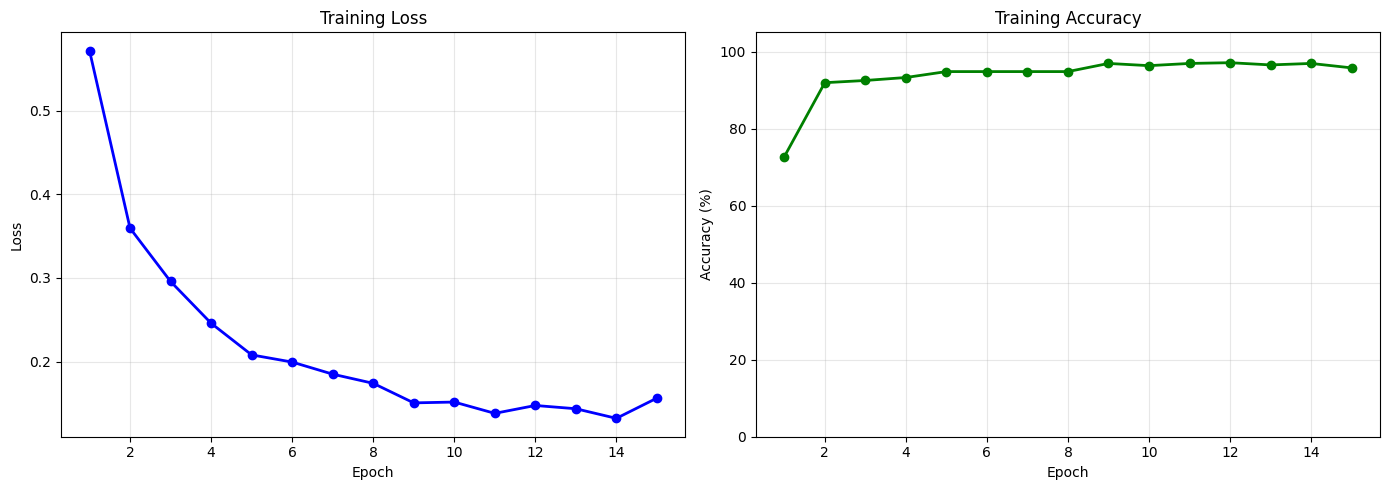

In [8]:
#============================================================
# CELL 8: Plot training progress
# ============================================================
#
# WHAT THIS DOES:
# Shows two charts side by side:
#   - Loss over time: should go DOWN (model making fewer errors)
#   - Accuracy over time: should go UP (model getting more right)
#
# WHAT TO LOOK FOR:
#   ✓ Good: Loss decreasing, accuracy increasing, both stabilizing
#   Concerning: Loss going up after initially decreasing (overfitting)
#   Concerning: Accuracy stuck at ~50% (model isn't learning, basically guessing)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: Loss over epochs
ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', linewidth=2)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

# Right chart: Accuracy over epochs
ax2.plot(range(1, NUM_EPOCHS+1), train_accs, 'g-o', linewidth=2)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim([0, 105])    # Set y-axis from 0% to 105% for clean look
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TEST SET RESULTS (clips the model never saw during training)
              precision    recall  f1-score   support

        Real       0.60      0.87      0.71        70
          AI       0.76      0.41      0.54        70

    accuracy                           0.64       140
   macro avg       0.68      0.64      0.62       140
weighted avg       0.68      0.64      0.62       140



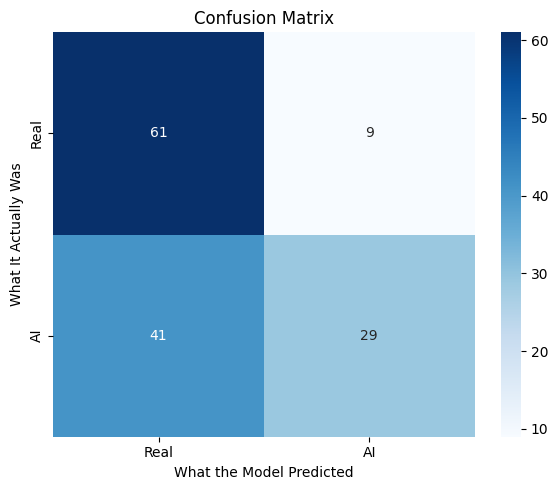

In [9]:
#============================================================
# CELL 9: Evaluate on test set
# ============================================================
#
# WHAT THIS DOES:
# Tests the model on clips it has NEVER seen during training.
# This is the honest measure of how good our model really is.
#
# Training accuracy can be misleading — a model might just memorize
# the training data (called "overfitting"). Test accuracy tells us
# if the model actually learned the difference between AI and Real.
#
# We show two things:
#   1. Classification Report: precision, recall, F1-score per class
#      - Precision: "When the model says AI, how often is it right?"
#      - Recall: "Of all actual AI clips, how many did the model catch?"
#      - F1: A combined score (harmonic mean of precision and recall)
#
#   2. Confusion Matrix: a 2×2 grid showing:
#      - Top-left:     Real clips correctly identified as Real (True Negative)
#      - Top-right:    Real clips wrongly called AI (False Positive)
#      - Bottom-left:  AI clips wrongly called Real (False Negative)
#      - Bottom-right: AI clips correctly identified as AI (True Positive)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set model to evaluation mode (disables dropout — we want full model for testing)
model.eval()

all_preds = []    # Will store all model predictions
all_labels = []   # Will store all true labels

# torch.no_grad() tells PyTorch "we're not training, don't track gradients"
# This saves memory and speeds things up
with torch.no_grad():
    for batch_frames, batch_labels in test_loader:
        batch_frames = batch_frames.to(device)

        # Get model predictions
        outputs = model(batch_frames)
        _, predicted = torch.max(outputs, 1)

        # Move results back to CPU and convert to regular Python lists
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

# Print detailed metrics
print("=" * 50)
print("TEST SET RESULTS (clips the model never saw during training)")
print("=" * 50)
print(classification_report(
    all_labels, all_preds,
    target_names=["Real", "AI"]
))

# Draw the confusion matrix as a heatmap
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Real", "AI"],
    yticklabels=["Real", "AI"],
    ax=ax
)
ax.set_xlabel("What the Model Predicted")
ax.set_ylabel("What It Actually Was")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
#============================================================
# CELL 10: Score EVERY clip and validate against filename labels
# ============================================================
#
# WHAT THIS DOES:
# This is the MOST IMPORTANT cell for the game. It runs the trained
# model on ALL 66 clips and produces a JSON file containing:
#
#   - The model's prediction (AI or Real) for each clip
#   - The model's confidence (0.0 to 1.0, where 1.0 = "definitely AI")
#   - A difficulty score for the game (1-10)
#   - Whether the model agreed with the filename label
#
# SMART THRESHOLD (instead of just using 0.5):
#   Our model is biased — it tends to say "Real" too often.
#   If we use 0.5 as the cutoff, many AI clips get mislabeled as Real
#   because their confidence is 0.45 or 0.48 — close but just under 0.5.
#
#   Instead, we TEST every possible threshold from 0.10 to 0.90 and
#   pick whichever one gives the highest accuracy on our data.
#   For example, the best threshold might be 0.35 — meaning anything
#   above 0.35 gets called AI. This compensates for the model's bias.
#
# HOW CONFIDENCE BECOMES DIFFICULTY:
#   - Clips where the model's confidence is near the threshold are "hard"
#     (the model is barely sure → difficulty close to 10)
#   - Clips where the model's confidence is far from the threshold are "easy"
#     (the model is very sure → difficulty close to 1)
#
# HOW SOFTMAX WORKS:
#   The model outputs two raw scores (called "logits"), e.g., [1.2, 3.8]
#   Softmax converts these into probabilities that sum to 1.0, e.g., [0.07, 0.93]
#   So: 7% chance Real, 93% chance AI → model is 93% confident it's AI.
#
# THE CELL WORKS IN THREE PASSES:
#   Pass 1: Score every clip (get confidence numbers)
#   Pass 2: Find the best threshold (test all possibilities)
#   Pass 3: Build final results using the best threshold
#
#   RAM-SAVING: We load one frame at a time from disk, score it,
#    then discard it before loading the next one.

import json
from torch.nn.functional import softmax

# Switch model to evaluation mode
# This turns off dropout so the model uses all 1280 features
model.eval()

# ================================================================
# PASS 1: Score every clip
# ================================================================
# We loop through all 66 clips and get the model's AI confidence
# for each one. We store the results in a temporary list.
# We DON'T make any AI/Real decisions yet — that comes in Pass 3
# after we know the best threshold.

clip_confidences = []

print("Pass 1: Scoring all clips...\n")

for clip in all_data:
    frame_scores = []

    # Score each frame individually, loading one at a time from disk
    for path in clip["frame_paths"]:
        # Load the frame from disk
        img = Image.open(path).convert("RGB")

        # Prepare the frame:
        # 1. Apply transforms (resize to 224x224, normalize)
        # 2. unsqueeze(0) adds a "batch" dimension — the model expects
        #    shape [batch_size, channels, height, width], not just [C, H, W]
        # 3. Move to CPU/GPU (whichever device the model is on)
        img_tensor = transform(img).unsqueeze(0).to(device)

        # Close the image — we don't need it anymore, free the RAM
        img.close()

        # torch.no_grad() tells PyTorch "we're not training, don't
        # track gradients" — saves memory and speeds things up
        with torch.no_grad():
            output = model(img_tensor)              # Raw scores: [score_real, score_ai]
            probs = softmax(output, dim=1)          # Convert to probabilities (sum to 1.0)
            ai_confidence = probs[0][1].item()      # Grab the AI probability
            frame_scores.append(ai_confidence)

        # Delete the tensor from memory — we saved the score, don't need the image
        del img_tensor

    # Average confidence across all frames of this clip
    # More stable than using just one frame
    avg_confidence = sum(frame_scores) / len(frame_scores)

    # Store the results for this clip (we'll use them in Pass 2 and 3)
    clip_confidences.append({
        "clip": clip,
        "avg_confidence": avg_confidence,
        "frame_scores": frame_scores
    })

print(f"Scored {len(clip_confidences)} clips\n")

# ================================================================
# PASS 2: Find the best threshold
# ================================================================
# The default threshold is 0.5 — if AI confidence > 0.5, call it AI.
# But our model is biased toward Real, so 0.5 might not be optimal.
#
# Here we test EVERY threshold from 0.10 to 0.90 (in steps of 0.01).
# That's 81 different thresholds. For each one, we count how many
# clips it gets right. The threshold with the most correct answers wins.
#
# Example: if threshold=0.35 gets 50 clips right, and threshold=0.50
# gets 45 clips right, we'll use 0.35 — it works better for our
# biased model.

best_threshold = 0.5   # Start with default
best_accuracy = 0      # Track highest accuracy found

print("Pass 2: Finding best threshold...\n")

for threshold in [i / 100 for i in range(10, 91)]:
    # Test this threshold on all clips
    correct = 0
    for item in clip_confidences:
        # Would this threshold get the right answer?
        model_says_ai = item["avg_confidence"] > threshold
        actually_ai = item["clip"]["label"] == 1
        if model_says_ai == actually_ai:
            correct += 1

    accuracy = correct / len(clip_confidences)

    # If this threshold is better than our current best, save it
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

print(f"   Best threshold: {best_threshold}")
print(f"   Accuracy at this threshold: {best_accuracy:.1%}")
print(f"   (Default 0.5 might give different/worse accuracy)\n")

# ================================================================
# PASS 3: Build final results using the best threshold
# ================================================================
# Now we go through all clips one more time and make final decisions
# using the best threshold we found. This produces the clip_scores.json
# file that the game app will use.

results = []

print("Pass 3: Building final results...\n")

for item in clip_confidences:
    clip = item["clip"]
    avg_confidence = item["avg_confidence"]
    frame_scores = item["frame_scores"]

    # Make the AI/Real decision using our optimized threshold
    # (instead of the default 0.5)
    model_says_ai = avg_confidence > best_threshold

    # Ground truth from the filename (what the Kaggle dataset says)
    actually_ai = clip["label"] == 1

    # Did the model get it right?
    correct = model_says_ai == actually_ai

    # ──── Calculate difficulty for the game (1 = easy, 10 = hard) ────
    #
    # Simple rule: how close is the confidence to 0.5?
    # 0.5 means the model has no idea → hardest (difficulty 10)
    # 0.0 or 1.0 means the model is certain → easiest (difficulty 1)
    #
    # We use 0.5 as the center for difficulty even though the
    # threshold for the AI/Real decision is different.
    # The threshold decides the LABEL. 0.5 measures UNCERTAINTY.
    #
    # Examples:
    #   confidence 0.99 → distance from 0.5 = 0.49 → difficulty 1.2
    #   confidence 0.75 → distance from 0.5 = 0.25 → difficulty 5.5
    #   confidence 0.52 → distance from 0.5 = 0.02 → difficulty 9.6
    #   confidence 0.07 → distance from 0.5 = 0.43 → difficulty 2.3
    #   confidence 0.50 → distance from 0.5 = 0.00 → difficulty 10.0

    distance_from_uncertain = abs(avg_confidence - 0.5)
    difficulty = round(1 + 9 * (1 - distance_from_uncertain * 2), 1)

    # Build the result dictionary for this clip
    # This is one entry in clip_scores.json — the game reads this
    result = {
        "filename": clip["filename"],
        "true_label": clip["label_name"],           # From filename: "ai" or "real"
        "model_prediction": "ai" if model_says_ai else "real",
        "model_confidence": round(avg_confidence, 4),  # 0.0 to 1.0
        "model_correct": correct,                    # Did model match the label?
        "difficulty": difficulty,                     # 1.0 to 10.0 for the game
        "threshold_used": best_threshold,            # What threshold we used
        "frame_scores": [round(s, 4) for s in frame_scores]  # Per-frame breakdown
    }
    results.append(result)

    # Print a line for each clip: ✓ if model was right, ✗ if wrong
    status = "✓" if correct else "✗"
    print(f"  {status} {clip['filename']:20s} | "
          f"True: {clip['label_name']:4s} | "
          f"Model: {'AI' if model_says_ai else 'Real':4s} ({avg_confidence:.1%}) | "
          f"Difficulty: {difficulty}")

# ──── Print summary ────
correct_count = sum(1 for r in results if r["model_correct"])
print(f"\n{'='*50}")
print(f"Model accuracy: {correct_count}/{len(results)} clips "
      f"({100*correct_count/len(results):.1f}%)")
print(f"Threshold used: {best_threshold} (instead of default 0.5)")
print(f"{'='*50}")

# ──── Save results to JSON file ────
# This file is what the game app will load.
# It contains every clip's prediction, confidence, and difficulty score.
output_path = os.path.join(BASE_PATH, "clip_scores.json")
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nSaved scores to: {output_path}")
print(f"   (This file will be used by the game app)")

Pass 1: Scoring all clips...

Scored 66 clips

Pass 2: Finding best threshold...

   Best threshold: 0.24
   Accuracy at this threshold: 95.5%
   (Default 0.5 might give different/worse accuracy)

Pass 3: Building final results...

  ✓ ai (1).mp4           | True: ai   | Model: AI   (90.0%) | Difficulty: 2.8
  ✓ ai (10).mp4          | True: ai   | Model: AI   (96.2%) | Difficulty: 1.7
  ✓ ai (11).mp4          | True: ai   | Model: AI   (88.5%) | Difficulty: 3.1
  ✓ ai (12).mp4          | True: ai   | Model: AI   (92.9%) | Difficulty: 2.3
  ✓ ai (13).mp4          | True: ai   | Model: AI   (97.4%) | Difficulty: 1.5
  ✓ ai (14).mp4          | True: ai   | Model: AI   (93.3%) | Difficulty: 2.2
  ✓ ai (15).mp4          | True: ai   | Model: AI   (99.0%) | Difficulty: 1.2
  ✓ ai (16).mp4          | True: ai   | Model: AI   (95.9%) | Difficulty: 1.7
  ✓ ai (17).mp4          | True: ai   | Model: AI   (92.6%) | Difficulty: 2.3
  ✓ ai (18).mp4          | True: ai   | Model: AI   (99.2%) | Diff

In [12]:
#============================================================
# CELL 11: Save the trained model + summary report
# ============================================================
#
# WHAT THIS DOES:
# Saves two files to your Google Drive:
#
# 1. ai_detector_model.pth — the trained model weights
#    You can reload this later without retraining. Useful if you
#    want to add more clips and re-score them.
#
# 2. model_report.json — a human-readable summary of how the model did,
#    including which clips it got wrong.
#
# WHAT TO DO NEXT:
# After this cell runs, go to your Google Drive folder "ai_reels_game".
# You should see clip_scores.json there. Download it along with your
# video files — we'll use them to build the game web app next.

# Save model weights
model_path = os.path.join(BASE_PATH, "ai_detector_model.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Save a summary report
report = {
    "total_clips": len(results),
    "model_accuracy": f"{100*correct_count/len(results):.1f}%",
    "correct_predictions": correct_count,
    "wrong_predictions": len(results) - correct_count,
    "wrong_clips": [r["filename"] for r in results if not r["model_correct"]],
}
report_path = os.path.join(BASE_PATH, "model_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"Report saved to: {report_path}")

# Show which clips the model struggled with
print(f"\nClips the model got WRONG:")
if report["wrong_clips"]:
    for r in results:
        if not r["model_correct"]:
            print(f"   - {r['filename']} "
                  f"(model said {r['model_prediction']} with "
                  f"{r['model_confidence']:.1%} confidence, "
                  f"actually {r['true_label']})")
else:
    print("   None! The model got everything right! 🎉")

print(f"\n{'='*50}")
print(f"NEXT STEPS:")
print(f"{'='*50}")
print(f"1. Check your Google Drive folder: {BASE_PATH}")
print(f"2. You should see: clip_scores.json, ai_detector_model.pth, model_report.json")
print(f"3. Download clip_scores.json and your video folders")
print(f"4. We'll build the game web app next!")

Model saved to: /content/drive/MyDrive/ai_reels_game/ai_detector_model.pth
Report saved to: /content/drive/MyDrive/ai_reels_game/model_report.json

Clips the model got WRONG:
   - real (19).mp4 (model said ai with 47.7% confidence, actually real)
   - real (22).mp4 (model said ai with 44.7% confidence, actually real)
   - real (28).mp4 (model said ai with 38.7% confidence, actually real)

NEXT STEPS:
1. Check your Google Drive folder: /content/drive/MyDrive/ai_reels_game
2. You should see: clip_scores.json, ai_detector_model.pth, model_report.json
3. Download clip_scores.json and your video folders
4. We'll build the game web app next!
